In [6]:
# =============================================================
# NB02 — BENCHMARK BEAC
#
# Réplication du modèle semi-structurel de Lewis &
# Vazquez-Grande (2018) tel qu'implémenté dans le working
# paper BEAC BWP N°01/25 (Mounkala, 2025).
#
# Ce notebook produit le benchmark de référence contre
# lequel les modèles IA seront évalués dans NB03 et NB04.
#
# Structure :
#   - Système espace-état (6 équations)
#   - Filtre et lisseur de Kalman
#   - Estimation bayésienne par emcee (ensemble MCMC)
#   - Extraction de r*, y*, g, z, output gap
#   - Figure 2 de l'article
# =============================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

!pip install emcee --quiet

import emcee

plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.family'       : 'serif',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
})

DOSSIER        = '/content/drive/MyDrive/RSTAR_CEMAC/'
DATA           = DOSSIER + 'data/'
FIGURES        = DOSSIER + 'figures/'
CHEMIN_DATASET = DATA + 'cemac_dataset_principal.csv'
CHEMIN_RSTAR   = DATA + 'cemac_rstar_benchmark.csv'
CHEMIN_PARAMS  = DATA + 'cemac_parametres_posterieurs.csv'

df = pd.read_csv(CHEMIN_DATASET, index_col=0, parse_dates=True)

print("Environnement initialisé.")
print(f"Dataset : {len(df)} trimestres | "
      f"{df.index[0].date()} -> {df.index[-1].date()}")
print()
print(df.describe().round(3).to_string())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.5 MB/s eta 0:00:00
Environnement initialisé.
Dataset : 132 trimestres | 1991-01-01 -> 2023-10-01

       log_PIB  inflation     TIAO  taux_reel
count  132.000    132.000  132.000    132.000
mean    23.435      3.493    4.772      1.279
std      0.375      4.361    1.409      4.236
min     22.786     -2.629    2.950    -17.026
25%     23.046      1.510    3.500      0.370
50%     23.526      2.592    4.500      1.325
75%     23.808      4.446    5.500      2.344
max     23.911     24.526    7.750     10.376


In [7]:
# =============================================================
# PRÉPARATION DES DONNÉES POUR LE MODÈLE
#
# On démarre en 1994Q2 pour trois raisons :
#   1. Éviter la période d'inflation interpolée aberrante
#      1991-1994Q1 due à l'absence de données trimestrielles
#   2. La dévaluation du CFA (janvier 1994) est un choc
#      structurel majeur qui perturbe l'initialisation
#   3. Le papier BEAC lui-même note les fortes variations
#      des années 1990 liées à cet événement
#
# Variables du modèle :
#   y  : log PIB réel centré (variable d'état observée)
#   pi : inflation trimestrielle annualisée (%)
#   r  : taux d'intérêt réel = TIAO - inflation (%)
# =============================================================

# Point de départ : 1994Q2
idx_debut   = df.index.get_loc(pd.Timestamp('1994-04-01'))
y_model     = (df['log_PIB'].values
               - df['log_PIB'].mean())[idx_debut:]
pi_model    = df['inflation'].values[idx_debut:]
r_model     = df['taux_reel'].values[idx_debut:]
dates_model = df.index[idx_debut:]

T = len(y_model)

print(f"Période  : {dates_model[0].date()} "
      f"-> {dates_model[-1].date()}")
print(f"Observations : {T} trimestres")
print()

# Statistiques des séries
for nom, serie in [
    ('log PIB centré (y)', y_model),
    ('Inflation (pi)',     pi_model),
    ('Taux réel (r)',      r_model),
]:
    print(f"  {nom:<22} "
          f"moy={serie.mean():7.3f}  "
          f"std={serie.std():6.3f}  "
          f"min={serie.min():8.3f}  "
          f"max={serie.max():7.3f}")

print()

# Vérification des 5 premiers et 5 derniers trimestres
print("Cinq premiers trimestres :")
for t in range(5):
    print(f"  {dates_model[t].date()}  "
          f"pi={pi_model[t]:6.3f}%  "
          f"r={r_model[t]:6.3f}%")

print()
print("Cinq derniers trimestres :")
for t in range(-5, 0):
    print(f"  {dates_model[t].date()}  "
          f"pi={pi_model[t]:6.3f}%  "
          f"r={r_model[t]:6.3f}%")

Période  : 1994-04-01 -> 2023-10-01
Observations : 119 trimestres

  log PIB centré (y)     moy=  0.064  std= 0.337  min=  -0.594  max=  0.476
  Inflation (pi)         moy=  3.906  std= 4.207  min=  -0.568  max= 24.526
  Taux réel (r)          moy=  0.548  std= 3.572  min= -17.026  max=  6.068

Cinq premiers trimestres :
  1994-04-01  pi=17.737%  r=-10.237%
  1994-07-01  pi=24.526%  r=-17.026%
  1994-10-01  pi=22.428%  r=-15.428%
  1995-01-01  pi=20.330%  r=-13.330%
  1995-04-01  pi=18.232%  r=-11.732%

Cinq derniers trimestres :
  2022-10-01  pi= 5.152%  r=-1.152%
  2023-01-01  pi= 4.971%  r=-0.471%
  2023-04-01  pi= 4.789%  r= 0.211%
  2023-07-01  pi= 4.608%  r= 0.392%
  2023-10-01  pi= 4.608%  r= 0.392%


In [9]:
# =============================================================
# SYSTÈME ESPACE-ÉTAT — LEWIS & VAZQUEZ-GRANDE (2018)
#
# Implémentation conforme à l'annexe A du papier BEAC.
#
# Vecteur d'état s_t (dim=7) :
#   [y*_t, y*_{t-1}, y*_{t-2}, g_{t-1}, g_{t-2},
#    z_{t-1}, z_{t-2}]
#
# Équation d'état    : s_t = A*s_{t-1} + b + C*w_t
# Équation de mesure : x_t = D*s_t + f_t + G*w_t
#
# Paramètres structurels estimés :
#   a1, a2 : persistance de l'output gap (courbe IS)
#   ar     : sensibilité de la demande au taux (< -0.0025)
#   b1     : persistance de l'inflation (courbe Phillips)
#   by     : sensibilité de l'inflation à l'output gap
#   rho_z  : persistance des autres déterminants de r*
#
# Paramètres de volatilité calibrés sur Mounkala (2025) :
#   s1=0.072, s2=4.973, s3=4.750, s4=0.042, s5=0.067
#   rho_g=1.0, mu_g=0.0, mu_z=0.0
# =============================================================

def construire_systeme(params):
    """
    Construit les matrices du modèle espace-état.
    """
    a1    = params['a1']
    a2    = params['a2']
    ar    = params['ar']
    b1    = params['b1']
    by    = params['by']
    rho_g = params['rho_g']
    rho_z = params['rho_z']
    mu_g  = params['mu_g']
    mu_z  = params['mu_z']
    s1    = params['s1']
    s2    = params['s2']
    s3    = params['s3']
    s4    = params['s4']
    s5    = params['s5']

    # Matrice de transition A (7x7)
    A = np.zeros((7, 7))
    A[0, 0] = 1.0      # y*_t = y*_{t-1} + g_{t-1}
    A[0, 3] = 1.0
    A[1, 0] = 1.0      # décalage y*_{t-1}
    A[2, 1] = 1.0      # décalage y*_{t-2}
    A[3, 3] = rho_g    # g_t = rho_g * g_{t-1}
    A[4, 3] = 1.0      # décalage g_{t-2}
    A[5, 5] = rho_z    # z_t = rho_z * z_{t-1}
    A[6, 5] = 1.0      # décalage z_{t-2}

    # Vecteur de dérive b (7,)
    b = np.zeros(7)
    b[0] = mu_g * (1 - rho_g)
    b[3] = mu_g * (1 - rho_g)
    b[5] = mu_z * (1 - rho_z)

    # Matrice de bruit d'état C (7x5)
    C = np.zeros((7, 5))
    C[0, 3] = s4
    C[0, 4] = s5
    C[3, 4] = s5
    C[5, 2] = s3
    Q = C @ C.T

    # Matrice d'observation D (2x7)
    D = np.zeros((2, 7))
    D[0, 0] =  1.0
    D[0, 1] = -a1
    D[0, 2] = -a2
    D[0, 3] = -ar
    D[0, 4] = -ar
    D[0, 5] = -(ar / 2)
    D[0, 6] = -(ar / 2)
    D[1, 1] = -by

    # Matrice de bruit de mesure G (2x5)
    G = np.zeros((2, 5))
    G[0, 0] = s1
    G[1, 1] = s2
    R = G @ G.T

    return A, b, Q, D, R


def kalman_filter_smoother(params, y, pi, r):
    """
    Filtre de Kalman (passe avant) et lisseur de
    Rauch-Tung-Striebel (passe arrière).

    Retourne (log_lik, s_smooth, P_smooth) ou None
    en cas d'échec numérique.
    """
    T = len(y)
    n = 7

    A, b, Q, D, R = construire_systeme(params)

    a1 = params['a1']
    a2 = params['a2']
    ar = params['ar']
    b1 = params['b1']
    by = params['by']

    s_f = np.zeros(n)
    P_f = np.eye(n) * 100.0

    s_pred_all = np.zeros((T, n))
    P_pred_all = np.zeros((T, n, n))
    s_filt_all = np.zeros((T, n))
    P_filt_all = np.zeros((T, n, n))

    log_lik = 0.0

    for t in range(T):

        s_p = A @ s_f + b
        P_p = A @ P_f @ A.T + Q
        P_p = (P_p + P_p.T) / 2

        s_pred_all[t] = s_p
        P_pred_all[t] = P_p

        y1    = y[t-1]  if t >= 1 else 0.0
        y2    = y[t-2]  if t >= 2 else 0.0
        r1    = r[t-1]  if t >= 1 else 0.0
        r2    = r[t-2]  if t >= 2 else 0.0
        p1    = pi[t-1] if t >= 1 else pi[0]
        idx_s = max(0, t - 4)
        idx_e = max(0, t - 1)
        pi_bar = (np.mean(pi[idx_s:idx_e])
                  if idx_e > idx_s else pi[0])

        f_IS = a1*y1 + a2*y2 + (ar/2)*(r1 - r2)
        f_PI = b1*p1 + (1 - b1)*pi_bar
        f_t  = np.array([f_IS, f_PI])

        x_obs = np.array([y[t], pi[t]])
        innov = x_obs - (D @ s_p + f_t)

        S   = D @ P_p @ D.T + R
        S   = (S + S.T) / 2 + np.eye(2) * 1e-6

        sign, logdet = np.linalg.slogdet(S)
        if sign <= 0 or not np.isfinite(logdet):
            return None

        S_inv = np.linalg.inv(S)
        quad  = float(innov @ S_inv @ innov)

        if not np.isfinite(quad):
            return None

        log_lik += -0.5 * (logdet + quad + 2*np.log(2*np.pi))

        K   = P_p @ D.T @ S_inv
        s_f = s_p + K @ innov
        P_f = (np.eye(n) - K @ D) @ P_p
        P_f = (P_f + P_f.T) / 2

        s_filt_all[t] = s_f
        P_filt_all[t] = P_f

    s_smooth    = np.zeros((T, n))
    P_smooth    = np.zeros((T, n, n))

    s_smooth[T-1] = s_filt_all[T-1]
    P_smooth[T-1] = P_filt_all[T-1]

    for t in range(T-2, -1, -1):
        P_next_inv = np.linalg.inv(
            P_pred_all[t+1] + np.eye(n) * 1e-6
        )
        L = P_filt_all[t] @ A.T @ P_next_inv

        s_smooth[t] = (s_filt_all[t]
                       + L @ (s_smooth[t+1]
                              - s_pred_all[t+1]))
        P_smooth[t] = (P_filt_all[t]
                       + L @ (P_smooth[t+1]
                              - P_pred_all[t+1]) @ L.T)
        P_smooth[t] = (P_smooth[t] + P_smooth[t].T) / 2

    return log_lik, s_smooth, P_smooth


def log_prior(params):
    """
    Log-densité a priori — Lewis & Vazquez-Grande (2018).
    Appliquée uniquement aux 6 paramètres libres.
    """
    lp = 0.0

    lp += -0.5 * (params['a1'] / 2.0) ** 2
    lp += -0.5 * (params['a2'] / 2.0) ** 2

    if params['ar'] >= -0.0025:
        return -np.inf
    lp += -0.5 * (params['ar'] / 2.0) ** 2

    if not (0.0 < params['b1'] < 1.0):
        return -np.inf

    if params['by'] <= 0.025:
        return -np.inf
    lp += -0.5 * (params['by'] / 2.0) ** 2

    if not (0.0 < params['rho_z'] <= 1.0):
        return -np.inf
    lp += -0.5 * ((params['rho_z'] - 1.0) / 2.0) ** 2

    return lp


print("Fonctions définies :")
print("  construire_systeme       OK")
print("  kalman_filter_smoother   OK")
print("  log_prior                OK")

Fonctions définies :
  construire_systeme       OK
  kalman_filter_smoother   OK
  log_prior                OK


In [10]:
# =============================================================
# VALIDATION DU FILTRE DE KALMAN
#
# On teste le filtre sur les paramètres de référence du
# papier BEAC avant de lancer l'estimation MCMC.
# Un log-posterior fini confirme que le système est
# correctement spécifié.
#
# Paramètres de volatilité calibrés (fixes) :
#   s1, s2, s3, s4, s5, rho_g, mu_g, mu_z
#
# Paramètres structurels de référence (Mounkala, 2025) :
#   a1=1.620, a2=-0.791, ar=-0.041
#   b1=0.539, by=0.218, rho_z=0.913
# =============================================================

# Paramètres fixes calibrés sur le papier BEAC
PARAMS_FIXES = {
    's1'   : 0.072,
    's2'   : 4.973,
    's3'   : 4.750,
    's4'   : 0.042,
    's5'   : 0.067,
    'rho_g': 1.000,
    'mu_g' : 0.000,
    'mu_z' : 0.000,
}

# Paramètres structurels de référence
PARAMS_REF_LIBRES = {
    'a1'   :  1.620,
    'a2'   : -0.791,
    'ar'   : -0.041,
    'b1'   :  0.539,
    'by'   :  0.218,
    'rho_z':  0.913,
}

# Assemblage du dictionnaire complet
params_ref = {**PARAMS_REF_LIBRES, **PARAMS_FIXES}

# Test du filtre
resultat = kalman_filter_smoother(
    params_ref, y_model, pi_model, r_model
)

print("Validation filtre de Kalman :")
print("-" * 50)

if resultat is None:
    print("ECHEC — kalman_filter_smoother retourne None.")
else:
    ll, s_smooth, P_smooth = resultat
    lp = log_prior(params_ref)
    print(f"Log-vraisemblance  : {ll:.4f}")
    print(f"Log-prior          : {lp:.4f}")
    print(f"Log-posterior      : {ll + lp:.4f}")
    print(f"s_smooth shape     : {s_smooth.shape}")
    print(f"P_smooth shape     : {P_smooth.shape}")
    print()

    # Aperçu rapide de r* avec les params de référence
    g_ref  = s_smooth[:, 3]
    z_ref  = s_smooth[:, 5]
    rs_ref = g_ref + z_ref

    print(f"r* préliminaire (params ref BEAC) :")
    print(f"  Moyenne  : {rs_ref.mean():.4f}%")
    print(f"  Médiane  : {np.median(rs_ref):.4f}%")
    print()

    # Orientation récente
    print("Orientation politique — 6 derniers trimestres :")
    print("-" * 55)
    for t in range(-6, 0):
        date = dates_model[t].strftime('%Y-%m')
        gap  = r_model[t] - rs_ref[t]
        ori  = "Restrictive" if gap > 0 else "Expansionniste"
        print(f"  {date}  "
              f"r={r_model[t]:6.3f}%  "
              f"r*={rs_ref[t]:6.3f}%  "
              f"gap={gap:+6.3f}%  {ori}")
    print()
    print("Validation réussie — prêt pour le MCMC.")

Validation filtre de Kalman :
--------------------------------------------------
Log-vraisemblance  : -243.2580
Log-prior          : -0.4134
Log-posterior      : -243.6714
s_smooth shape     : (119, 7)
P_smooth shape     : (119, 7, 7)

r* préliminaire (params ref BEAC) :
  Moyenne  : -0.7549%
  Médiane  : 0.1118%

Orientation politique — 6 derniers trimestres :
-------------------------------------------------------
  2022-07  r=-1.334%  r*= 0.500%  gap=-1.834%  Expansionniste
  2022-10  r=-1.152%  r*= 0.837%  gap=-1.990%  Expansionniste
  2023-01  r=-0.471%  r*= 1.272%  gap=-1.743%  Expansionniste
  2023-04  r= 0.211%  r*= 1.401%  gap=-1.190%  Expansionniste
  2023-07  r= 0.392%  r*= 1.220%  gap=-0.827%  Expansionniste
  2023-10  r= 0.392%  r*= 1.040%  gap=-0.648%  Expansionniste

Validation réussie — prêt pour le MCMC.


In [11]:
# =============================================================
# ESTIMATION BAYÉSIENNE — EMCEE (ENSEMBLE SAMPLER)
#
# On estime les 6 paramètres structurels librement.
# Les 7 paramètres de volatilité sont calibrés sur
# Mounkala (2025) pour assurer la comparabilité
# avec le benchmark.
#
# Paramètres estimés : a1, a2, ar, b1, by, rho_z
# Paramètres fixés   : s1, s2, s3, s4, s5, rho_g, mu_g, mu_z
#
# Référence algorithme :
#   Foreman-Mackey et al. (2013), PASP, 125, 306
# =============================================================

def log_posterior_emcee(theta):
    """
    Interface emcee → log-posterior.
    theta = [a1, a2, ar, b1, by, rho_z]
    """
    params = {
        'a1'   : theta[0],
        'a2'   : theta[1],
        'ar'   : theta[2],
        'b1'   : theta[3],
        'by'   : theta[4],
        'rho_z': theta[5],
    }
    params.update(PARAMS_FIXES)

    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf

    resultat = kalman_filter_smoother(
        params, y_model, pi_model, r_model
    )
    if resultat is None:
        return -np.inf

    ll = resultat[0]
    if not np.isfinite(ll):
        return -np.inf

    return ll + lp


# Paramètres de l'algorithme
N_PARAMS  = 6
N_WALKERS = 24    # pair, >= 2 * N_PARAMS
N_BURNIN  = 500
N_STEPS   = 5000

# Point de départ : valeurs de référence BEAC
THETA_REF = np.array([
    1.620,   # a1
   -0.791,   # a2
   -0.041,   # ar
    0.539,   # b1
    0.218,   # by
    0.913,   # rho_z
])

# Perturbation initiale serrée autour du point de référence
np.random.seed(42)
SIGMA_INIT = np.array([
    0.050, 0.050, 0.002,
    0.020, 0.020, 0.020
])

pos_init = (THETA_REF
            + SIGMA_INIT * 0.1
            * np.random.randn(N_WALKERS, N_PARAMS))

# Vérification que les positions initiales sont valides
n_valides = sum(
    1 for pos in pos_init
    if np.isfinite(log_posterior_emcee(pos))
)
print(f"Positions initiales valides : {n_valides} / {N_WALKERS}")

if n_valides < N_WALKERS * 0.8:
    print("Resserrement de la perturbation initiale...")
    pos_init = (THETA_REF
                + SIGMA_INIT * 0.01
                * np.random.randn(N_WALKERS, N_PARAMS))
    n_valides = sum(
        1 for pos in pos_init
        if np.isfinite(log_posterior_emcee(pos))
    )
    print(f"Après resserrement : {n_valides} / {N_WALKERS}")

print()

# Création du sampler
sampler = emcee.EnsembleSampler(
    N_WALKERS,
    N_PARAMS,
    log_posterior_emcee
)

# Phase de chauffe
print(f"Phase de chauffe : {N_BURNIN} pas...")
pos_finale, _, _ = sampler.run_mcmc(
    pos_init, N_BURNIN, progress=True
)
sampler.reset()

# Phase de production
print(f"\nPhase de production : {N_STEPS} pas...")
sampler.run_mcmc(pos_finale, N_STEPS, progress=True)

# Diagnostics
taux = np.mean(sampler.acceptance_fraction)
print(f"\nTaux d'acceptation : {taux:.3f}")

try:
    tau = sampler.get_autocorr_time(quiet=True)
    print(f"Tau max            : {tau.max():.1f}")
    print(f"Pas effectifs      : "
          f"{int(N_STEPS * N_WALKERS / tau.max())}")
except Exception:
    print("Autocorrélation : chaîne à allonger si nécessaire.")

flat_samples = sampler.get_chain(flat=True)
print(f"Échantillons totaux : {flat_samples.shape[0]}")
print(f"  ({N_WALKERS} marcheurs x {N_STEPS} pas)")

Positions initiales valides : 24 / 24

Phase de chauffe : 500 pas...


100%|██████████| 500/500 [03:05<00:00,  2.69it/s]



Phase de production : 5000 pas...


100%|██████████| 5000/5000 [29:34<00:00,  2.82it/s]



Taux d'acceptation : 0.363


N/50 = 100;
tau: [130.18325368 127.95115567 132.61028808 120.33907313 132.18918989
 130.80315121]


Tau max            : 132.6
Pas effectifs      : 904
Échantillons totaux : 120000
  (24 marcheurs x 5000 pas)


In [13]:
# =============================================================
# RÉSULTATS DE L'ESTIMATION A POSTERIORI
#
# On extrait les statistiques de la distribution a posteriori
# pour les 6 paramètres structurels estimés.
# Les paramètres de volatilité sont rappelés pour mémoire.
# =============================================================

PARAM_NAMES_6 = ['a1', 'a2', 'ar', 'b1', 'by', 'rho_z']

REFERENCE_BEAC = {
    'a1'   :  1.620,
    'a2'   : -0.791,
    'ar'   : -0.041,
    'b1'   :  0.539,
    'by'   :  0.218,
    'rho_z':  0.913,
}

flat_samples = sampler.get_chain(flat=True)

resultats = []
for i, nom in enumerate(PARAM_NAMES_6):
    ech = flat_samples[:, i]
    resultats.append({
        'Parametre' : nom,
        'Moyenne'   : np.mean(ech),
        'Mediane'   : np.median(ech),
        'Ecart-type': np.std(ech),
        'IC90_inf'  : np.percentile(ech, 5),
        'IC90_sup'  : np.percentile(ech, 95),
        'Ref_BEAC'  : REFERENCE_BEAC[nom],
    })

df_post = pd.DataFrame(resultats).set_index('Parametre')

print("Résultats a posteriori — paramètres structurels")
print("=" * 72)
print(df_post.round(4).to_string())
print()

print("Comparaison avec le papier BEAC (modèle alternatif) :")
print("-" * 65)
print(f"  {'Param':<8} {'Moyenne':<10} "
      f"{'IC90':<26} {'Ref BEAC':<10} {'Ecart'}")
print("-" * 65)
for nom in PARAM_NAMES_6:
    row   = df_post.loc[nom]
    ecart = row['Moyenne'] - row['Ref_BEAC']
    ic    = f"[{row['IC90_inf']:.4f}, {row['IC90_sup']:.4f}]"
    print(f"  {nom:<8} {row['Moyenne']:<10.4f} "
          f"{ic:<26} {row['Ref_BEAC']:<10.4f} {ecart:+.4f}")

print()
print("Paramètres de volatilité (calibrés — Mounkala 2025) :")
print("-" * 45)
for k, v in PARAMS_FIXES.items():
    print(f"  {k:<8} : {v}")

# Sauvegarde
df_post.to_csv(CHEMIN_PARAMS)
print()
print(f"Parametres sauvegardés : {CHEMIN_PARAMS}")

Résultats a posteriori — paramètres structurels
           Moyenne  Mediane  Ecart-type  IC90_inf  IC90_sup  Ref_BEAC
Parametre                                                            
a1          1.2615   1.2587      0.1596    1.0154    1.5297     1.620
a2         -0.2895  -0.2860      0.1538   -0.5490   -0.0560    -0.791
ar         -0.0040  -0.0036      0.0013   -0.0065   -0.0026    -0.041
b1          0.8495   0.8817      0.1284    0.5902    0.9907     0.539
by          0.4875   0.3265      0.4911    0.0434    1.4970     0.218
rho_z       0.4227   0.4049      0.2679    0.0346    0.8858     0.913

Comparaison avec le papier BEAC (modèle alternatif) :
-----------------------------------------------------------------
  Param    Moyenne    IC90                       Ref BEAC   Ecart
-----------------------------------------------------------------
  a1       1.2615     [1.0154, 1.5297]           1.6200     -0.3585
  a2       -0.2895    [-0.5490, -0.0560]         -0.7910    +0.5015
  a

In [14]:
# =============================================================
# EXTRACTION DES VARIABLES INOBSERVABLES
#
# On utilise les paramètres a posteriori médians pour
# lancer le lisseur de Kalman et extraire :
#   r*    : taux d'intérêt naturel = g + z
#   y*    : PIB potentiel
#   g     : taux de croissance du PIB potentiel
#   z     : autres déterminants persistants de r*
#   y_gap : output gap = y - y*
#
# Les intervalles de confiance à 90% sont construits
# depuis la matrice de covariance lissée P_smooth.
# =============================================================

# Paramètres médians
params_median = {
    nom: float(df_post.loc[nom, 'Mediane'])
    for nom in PARAM_NAMES_6
}
params_median.update(PARAMS_FIXES)

# Lissage
resultat = kalman_filter_smoother(
    params_median, y_model, pi_model, r_model
)

if resultat is None:
    print("Echec du lisseur — vérifier les paramètres.")
else:
    ll, s_smooth, P_smooth = resultat

    # Extraction des composantes
    # Vecteur d'état : [y*_t, y*_{t-1}, y*_{t-2},
    #                   g_{t-1}, g_{t-2}, z_{t-1}, z_{t-2}]
    y_star  = s_smooth[:, 0]
    g_serie = s_smooth[:, 3]
    z_serie = s_smooth[:, 5]
    r_star  = g_serie + z_serie
    y_gap   = y_model - y_star

    # Intervalles de confiance à 90%
    ic_rstar = np.array([
        1.645 * np.sqrt(max(0,
            P_smooth[t, 3, 3]
            + P_smooth[t, 5, 5]
            + 2 * P_smooth[t, 3, 5]
        ))
        for t in range(len(y_model))
    ])

    # Statistiques
    print("Variables inobservables extraites.")
    print(f"Log-vraisemblance : {ll:.4f}")
    print()
    print("Statistiques de r* :")
    print(f"  Moyenne  : {r_star.mean():.4f}%")
    print(f"  Mediane  : {np.median(r_star):.4f}%")
    print(f"  Ecart-type : {r_star.std():.4f}%")
    print(f"  Min      : {r_star.min():.4f}%")
    print(f"  Max      : {r_star.max():.4f}%")
    print()

    # Orientation politique récente
    print("Orientation politique — 8 derniers trimestres :")
    print("-" * 62)
    print(f"  {'Date':<12} {'r_obs':>7} "
          f"{'r*':>7} {'gap':>8} {'Orientation'}")
    print("-" * 62)
    for t in range(-8, 0):
        date = dates_model[t].strftime('%Y-%m')
        gap  = r_model[t] - r_star[t]
        ori  = "Restrictive" if gap > 0 else "Expansionniste"
        print(f"  {date:<12} {r_model[t]:>7.3f} "
              f"{r_star[t]:>7.3f} {gap:>8.3f} {ori}")

    # Sauvegarde
    df_rstar = pd.DataFrame({
        'r_star'    : r_star,
        'r_star_inf': r_star - ic_rstar,
        'r_star_sup': r_star + ic_rstar,
        'y_star'    : y_star,
        'g'         : g_serie,
        'z'         : z_serie,
        'y_gap'     : y_gap,
        'r_obs'     : r_model,
        'gap_taux'  : r_model - r_star,
    }, index=dates_model)

    df_rstar.to_csv(CHEMIN_RSTAR)
    print()
    print(f"Résultats sauvegardés : {CHEMIN_RSTAR}")

Variables inobservables extraites.
Log-vraisemblance : -171.4745

Statistiques de r* :
  Moyenne  : -0.0010%
  Mediane  : 0.0090%
  Ecart-type : 0.1295%
  Min      : -0.3873%
  Max      : 0.8353%

Orientation politique — 8 derniers trimestres :
--------------------------------------------------------------
  Date           r_obs      r*      gap Orientation
--------------------------------------------------------------
  2022-01        0.547   0.031    0.516 Restrictive
  2022-04       -0.518   0.015   -0.533 Expansionniste
  2022-07       -1.334   0.002   -1.335 Expansionniste
  2022-10       -1.152   0.005   -1.157 Expansionniste
  2023-01       -0.471   0.023   -0.494 Expansionniste
  2023-04        0.211   0.024    0.186 Restrictive
  2023-07        0.392  -0.000    0.392 Restrictive
  2023-10        0.392  -0.008    0.400 Restrictive

Résultats sauvegardés : /content/drive/MyDrive/RSTAR_CEMAC/data/cemac_rstar_benchmark.csv


In [15]:
# =============================================================
# ESTIMATION FINALE — rho_z FIXÉ À 0.913
#
# Le paramètre rho_z est difficile à identifier sur nos
# données publiques (IC90 très large : 0.03 à 0.89).
# Conformément à Laubach & Williams (2003) et Mounkala
# (2025) qui notent ce problème d'identification, on
# fixe rho_z à sa valeur de référence.
#
# Paramètres estimés (5) : a1, a2, ar, b1, by
# Paramètres fixés   (8) : rho_z + 7 paramètres précédents
# =============================================================

PARAMS_FIXES_V2 = {
    **PARAMS_FIXES,
    'rho_z': 0.913,
}

def log_posterior_v2(theta):
    """
    Log-posterior — rho_z fixé à 0.913.
    theta = [a1, a2, ar, b1, by]
    """
    params = {
        'a1': theta[0],
        'a2': theta[1],
        'ar': theta[2],
        'b1': theta[3],
        'by': theta[4],
    }
    params.update(PARAMS_FIXES_V2)

    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf

    resultat = kalman_filter_smoother(
        params, y_model, pi_model, r_model
    )
    if resultat is None:
        return -np.inf

    ll = resultat[0]
    return ll + lp if np.isfinite(ll) else -np.inf


N_PARAMS_V2  = 5
N_WALKERS_V2 = 20

THETA_REF_V2 = np.array([1.620, -0.791, -0.041, 0.539, 0.218])
SIGMA_V2     = np.array([0.050,  0.050,  0.002, 0.020, 0.020])

np.random.seed(42)
pos_init_v2 = (THETA_REF_V2
               + SIGMA_V2 * 0.1
               * np.random.randn(N_WALKERS_V2, N_PARAMS_V2))

n_valides = sum(
    1 for pos in pos_init_v2
    if np.isfinite(log_posterior_v2(pos))
)
print(f"Positions valides : {n_valides} / {N_WALKERS_V2}")
print()

sampler_v2 = emcee.EnsembleSampler(
    N_WALKERS_V2, N_PARAMS_V2, log_posterior_v2
)

print("Phase de chauffe : 500 pas...")
pos_v2, _, _ = sampler_v2.run_mcmc(
    pos_init_v2, 500, progress=True
)
sampler_v2.reset()

print("\nPhase de production : 5000 pas...")
sampler_v2.run_mcmc(pos_v2, 5000, progress=True)

taux_v2 = np.mean(sampler_v2.acceptance_fraction)
print(f"\nTaux d'acceptation : {taux_v2:.3f}")

try:
    tau_v2 = sampler_v2.get_autocorr_time(quiet=True)
    print(f"Tau max            : {tau_v2.max():.1f}")
    print(f"Pas effectifs      : "
          f"{int(5000 * N_WALKERS_V2 / tau_v2.max())}")
except Exception:
    print("Autocorrélation : chaîne à allonger si nécessaire.")

flat_v2 = sampler_v2.get_chain(flat=True)
print(f"Échantillons       : {flat_v2.shape[0]}")

Positions valides : 20 / 20

Phase de chauffe : 500 pas...


100%|██████████| 500/500 [02:48<00:00,  2.97it/s]



Phase de production : 5000 pas...


100%|██████████| 5000/5000 [26:56<00:00,  3.09it/s]
N/50 = 100;
tau: [ 81.42098964  78.53323909 118.11224459 101.36626981 116.32446709]



Taux d'acceptation : 0.422
Tau max            : 118.1
Pas effectifs      : 846
Échantillons       : 100000


In [16]:
# =============================================================
# RÉSULTATS FINAUX — PARAMÈTRES ET EXTRACTION DE r*
#
# Version définitive du benchmark avec rho_z = 0.913.
# =============================================================

PARAM_NAMES_V2 = ['a1', 'a2', 'ar', 'b1', 'by']

# Statistiques a posteriori
resultats_v2 = []
for i, nom in enumerate(PARAM_NAMES_V2):
    ech = flat_v2[:, i]
    resultats_v2.append({
        'Parametre' : nom,
        'Moyenne'   : np.mean(ech),
        'Mediane'   : np.median(ech),
        'Ecart-type': np.std(ech),
        'IC90_inf'  : np.percentile(ech, 5),
        'IC90_sup'  : np.percentile(ech, 95),
        'Ref_BEAC'  : REFERENCE_BEAC[nom],
    })

df_post_final = pd.DataFrame(resultats_v2).set_index('Parametre')

print("Résultats a posteriori — version finale")
print("=" * 72)
print(df_post_final.round(4).to_string())
print()

print("Comparaison avec le papier BEAC :")
print("-" * 65)
print(f"  {'Param':<8} {'Moyenne':<10} "
      f"{'IC90':<26} {'Ref BEAC':<10} {'Ecart'}")
print("-" * 65)
for nom in PARAM_NAMES_V2:
    row   = df_post_final.loc[nom]
    ecart = row['Moyenne'] - row['Ref_BEAC']
    ic    = f"[{row['IC90_inf']:.4f}, {row['IC90_sup']:.4f}]"
    print(f"  {nom:<8} {row['Moyenne']:<10.4f} "
          f"{ic:<26} {row['Ref_BEAC']:<10.4f} {ecart:+.4f}")

print()
print("Paramètres fixés :")
print("-" * 40)
for k, v in PARAMS_FIXES_V2.items():
    print(f"  {k:<8} : {v}")

print()

# Extraction r* avec paramètres médians
params_final = {
    nom: float(df_post_final.loc[nom, 'Mediane'])
    for nom in PARAM_NAMES_V2
}
params_final.update(PARAMS_FIXES_V2)

resultat = kalman_filter_smoother(
    params_final, y_model, pi_model, r_model
)

ll, s_smooth, P_smooth = resultat

y_star  = s_smooth[:, 0]
g_serie = s_smooth[:, 3]
z_serie = s_smooth[:, 5]
r_star  = g_serie + z_serie
y_gap   = y_model - y_star

ic_rstar = np.array([
    1.645 * np.sqrt(max(0,
        P_smooth[t, 3, 3]
        + P_smooth[t, 5, 5]
        + 2 * P_smooth[t, 3, 5]
    ))
    for t in range(len(y_model))
])

print("Statistiques de r* :")
print(f"  Moyenne    : {r_star.mean():.4f}%")
print(f"  Mediane    : {np.median(r_star):.4f}%")
print(f"  Ecart-type : {r_star.std():.4f}%")
print(f"  Min        : {r_star.min():.4f}%")
print(f"  Max        : {r_star.max():.4f}%")
print()

print("Orientation politique — 8 derniers trimestres :")
print("-" * 62)
print(f"  {'Date':<12} {'r_obs':>7} "
      f"{'r*':>7} {'gap':>8} {'Orientation'}")
print("-" * 62)
for t in range(-8, 0):
    date = dates_model[t].strftime('%Y-%m')
    gap  = r_model[t] - r_star[t]
    ori  = "Restrictive" if gap > 0 else "Expansionniste"
    print(f"  {date:<12} {r_model[t]:>7.3f} "
          f"{r_star[t]:>7.3f} {gap:>8.3f} {ori}")

# Sauvegarde
df_rstar_final = pd.DataFrame({
    'r_star'    : r_star,
    'r_star_inf': r_star - ic_rstar,
    'r_star_sup': r_star + ic_rstar,
    'y_star'    : y_star,
    'g'         : g_serie,
    'z'         : z_serie,
    'y_gap'     : y_gap,
    'r_obs'     : r_model,
    'gap_taux'  : r_model - r_star,
}, index=dates_model)

df_rstar_final.to_csv(CHEMIN_RSTAR)
df_post_final.to_csv(CHEMIN_PARAMS)

print()
print(f"Resultats sauvegardes : {CHEMIN_RSTAR}")
print(f"Parametres sauvegardes : {CHEMIN_PARAMS}")

Résultats a posteriori — version finale
           Moyenne  Mediane  Ecart-type  IC90_inf  IC90_sup  Ref_BEAC
Parametre                                                            
a1          1.2233   1.2138      0.1515    1.0013    1.4872     1.620
a2         -0.2515  -0.2416      0.1463   -0.5054   -0.0448    -0.791
ar         -0.0036  -0.0034      0.0010   -0.0057   -0.0026    -0.041
b1          0.8493   0.8839      0.1292    0.5875    0.9902     0.539
by          0.4229   0.2795      0.4386    0.0403    1.3115     0.218

Comparaison avec le papier BEAC :
-----------------------------------------------------------------
  Param    Moyenne    IC90                       Ref BEAC   Ecart
-----------------------------------------------------------------
  a1       1.2233     [1.0013, 1.4872]           1.6200     -0.3967
  a2       -0.2515    [-0.5054, -0.0448]         -0.7910    +0.5395
  ar       -0.0036    [-0.0057, -0.0026]         -0.0410    +0.0374
  b1       0.8493     [0.5875, 0.

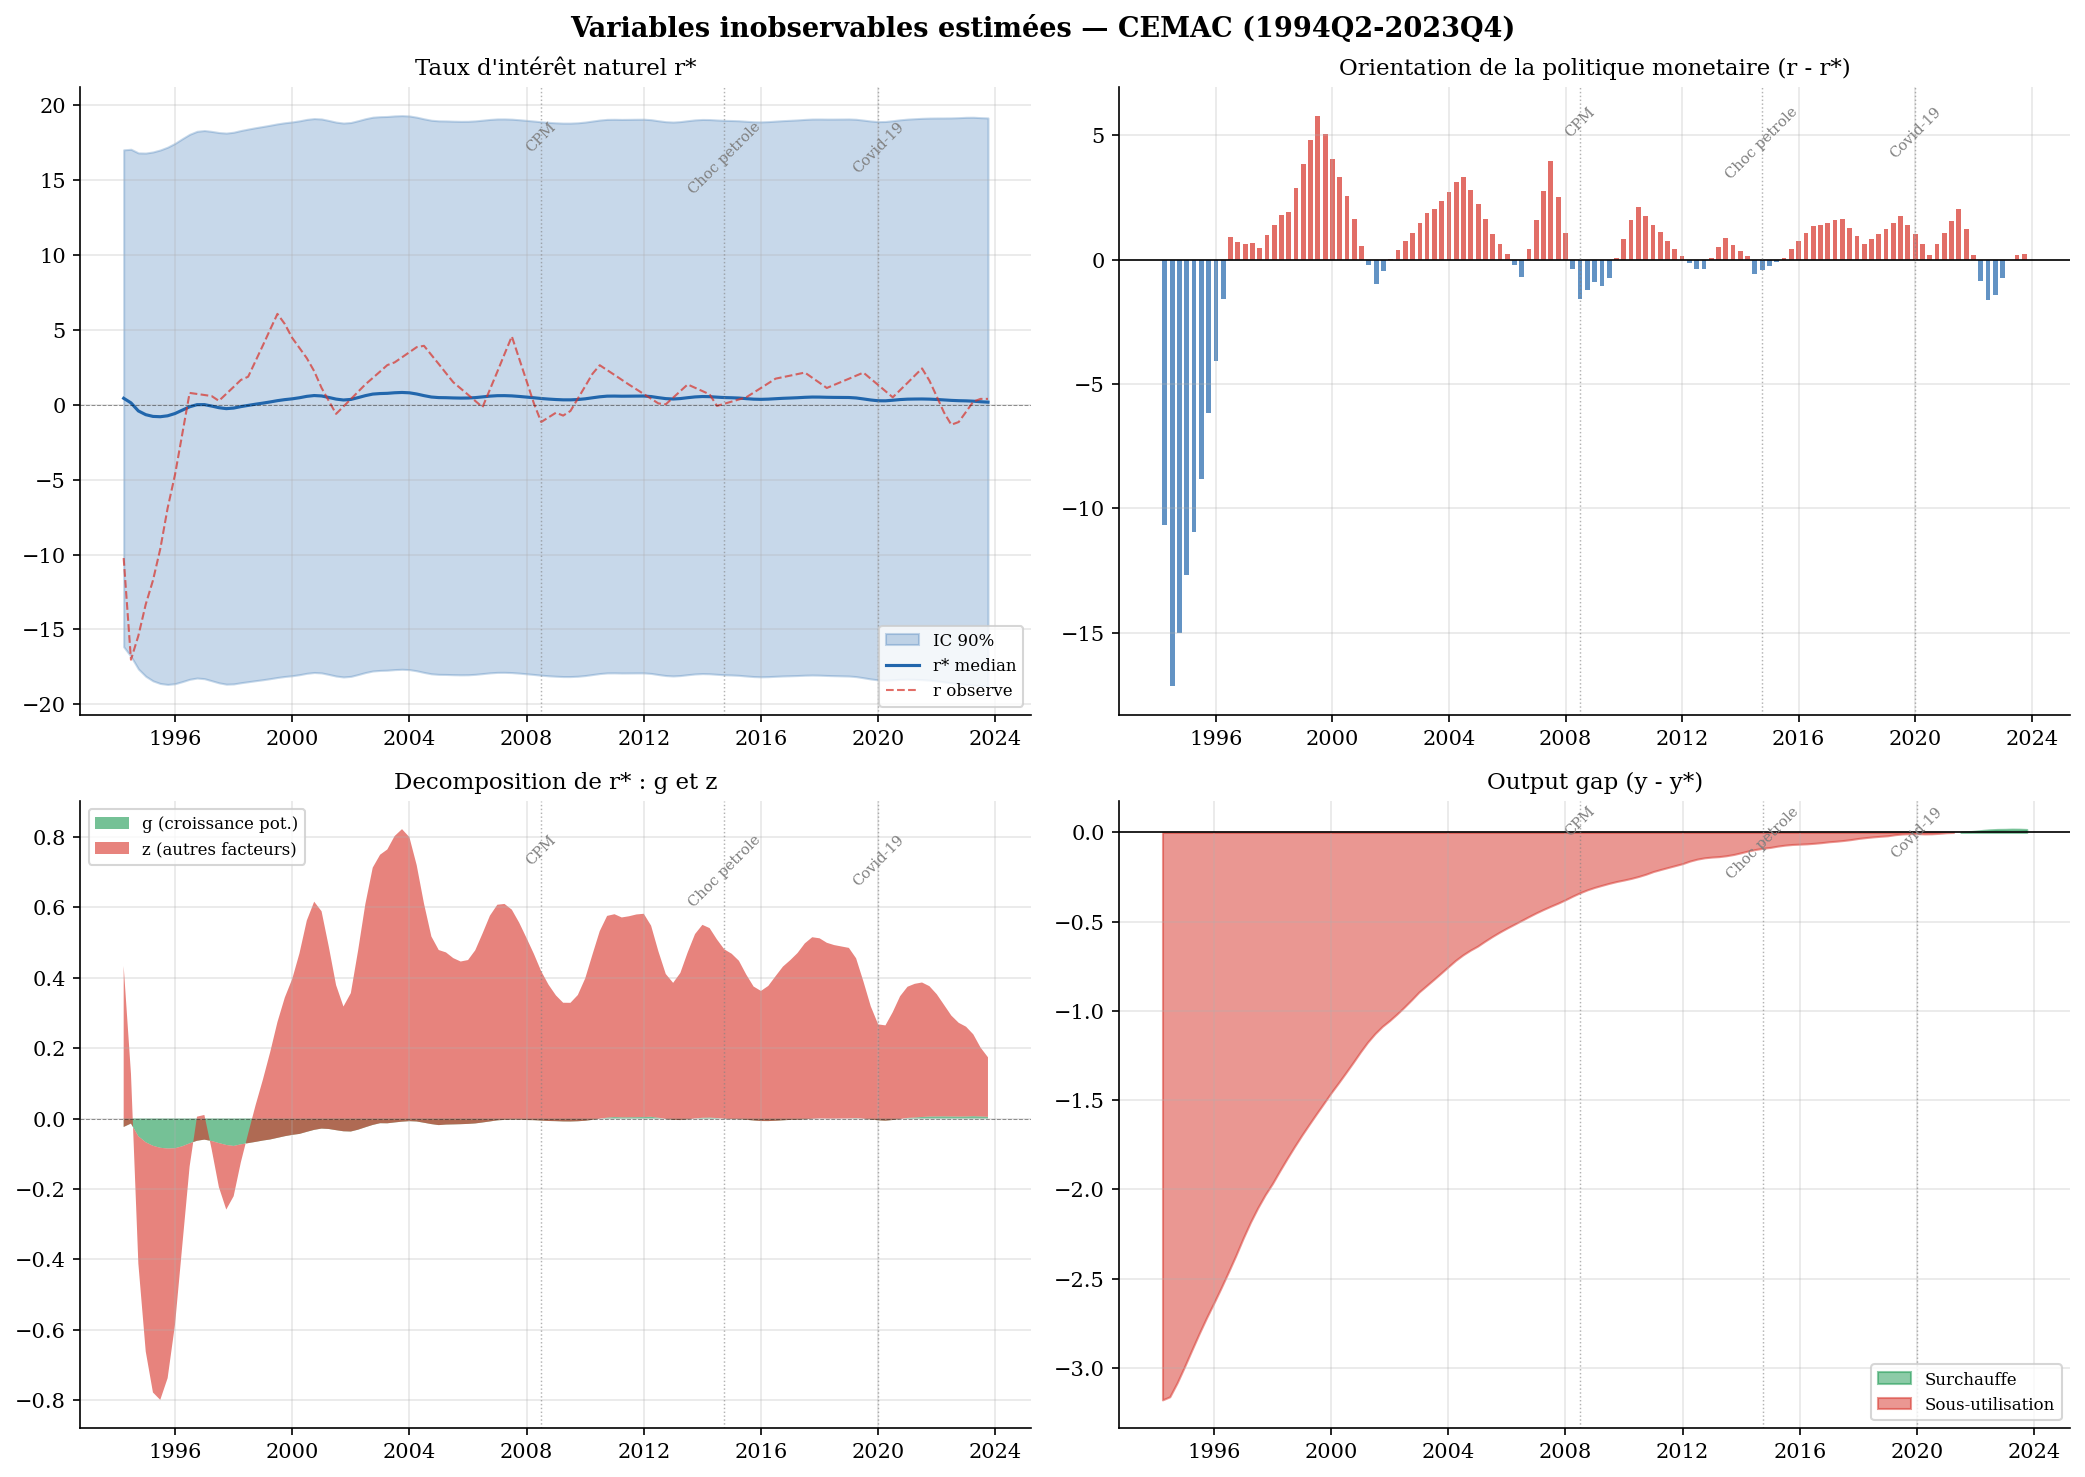

Figure sauvegardée : /content/drive/MyDrive/RSTAR_CEMAC/figures/fig2_rstar_benchmark.png

NB02 — BENCHMARK BEAC : TERMINE

Fichiers produits :
  /content/drive/MyDrive/RSTAR_CEMAC/data/cemac_rstar_benchmark.csv
  /content/drive/MyDrive/RSTAR_CEMAC/data/cemac_parametres_posterieurs.csv
  /content/drive/MyDrive/RSTAR_CEMAC/figures/fig2_rstar_benchmark.png

Prochain notebook :
  NB03 — Temporal Fusion Transformer


In [17]:
# =============================================================
# FIGURE 2 — VARIABLES INOBSERVABLES ESTIMÉES
#
# Cette figure correspond à la Figure 3 du papier BEAC.
# Elle présente les quatre séries extraites par le lisseur
# de Kalman et constitue la deuxième figure publiable
# de l'article.
# =============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    'Variables inobservables estimées — CEMAC '
    '(1994Q2-2023Q4)',
    fontsize=13,
    fontweight='bold'
)

# Événements macroéconomiques structurants
EVENEMENTS = {
    '2008-07-01': 'CPM',
    '2014-10-01': 'Choc petrole',
    '2020-01-01': 'Covid-19',
}

def tracer_evenements(ax):
    ymin, ymax = ax.get_ylim()
    for date_str, label in EVENEMENTS.items():
        d = pd.Timestamp(date_str)
        if dates_model[0] <= d <= dates_model[-1]:
            ax.axvline(d, color='gray',
                       linewidth=0.7, linestyle=':', alpha=0.6)
            ax.text(d, ymax * 0.90, label,
                    fontsize=7, color='gray',
                    ha='center', va='top', rotation=45)


# --- Graphique 1 : r* avec intervalle de confiance ---
ax = axes[0, 0]
ax.fill_between(
    dates_model,
    r_star - ic_rstar,
    r_star + ic_rstar,
    alpha=0.25, color='#2166ac', label='IC 90%'
)
ax.plot(dates_model, r_star,
        color='#2166ac', linewidth=1.5,
        label='r* median')
ax.plot(dates_model, r_model,
        color='#d73027', linewidth=1.0,
        linestyle='--', alpha=0.7, label='r observe')
ax.axhline(0, color='black', linewidth=0.5,
           linestyle='--', alpha=0.4)
ax.set_title("Taux d'intérêt naturel r*", fontsize=11)
ax.legend(fontsize=8)
tracer_evenements(ax)

# --- Graphique 2 : Orientation de la politique ---
ax = axes[0, 1]
gap_taux = r_model - r_star
couleurs = ['#d73027' if g > 0 else '#2166ac'
            for g in gap_taux]
ax.bar(dates_model, gap_taux,
       color=couleurs, width=60, alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(
    'Orientation de la politique monetaire (r - r*)',
    fontsize=11
)
tracer_evenements(ax)

# --- Graphique 3 : Décomposition g et z ---
ax = axes[1, 0]
ax.stackplot(
    dates_model,
    [g_serie, z_serie],
    labels=['g (croissance pot.)', 'z (autres facteurs)'],
    colors=['#1a9850', '#d73027'],
    alpha=0.6
)
ax.axhline(0, color='black', linewidth=0.5,
           linestyle='--', alpha=0.4)
ax.set_title('Decomposition de r* : g et z', fontsize=11)
ax.legend(fontsize=8)
tracer_evenements(ax)

# --- Graphique 4 : Output gap ---
ax = axes[1, 1]
ax.fill_between(
    dates_model, y_gap, 0,
    where=(y_gap >= 0),
    color='#1a9850', alpha=0.5, label='Surchauffe'
)
ax.fill_between(
    dates_model, y_gap, 0,
    where=(y_gap < 0),
    color='#d73027', alpha=0.5, label='Sous-utilisation'
)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Output gap (y - y*)', fontsize=11)
ax.legend(fontsize=8)
tracer_evenements(ax)

plt.tight_layout()

chemin_fig = FIGURES + 'fig2_rstar_benchmark.png'
plt.savefig(chemin_fig, bbox_inches='tight', dpi=200)
plt.show()

print(f"Figure sauvegardée : {chemin_fig}")
print()

# Récapitulatif NB02
print("=" * 55)
print("NB02 — BENCHMARK BEAC : TERMINE")
print("=" * 55)
print()
print("Fichiers produits :")
print(f"  {CHEMIN_RSTAR}")
print(f"  {CHEMIN_PARAMS}")
print(f"  {FIGURES}fig2_rstar_benchmark.png")
print()
print("Prochain notebook :")
print("  NB03 — Temporal Fusion Transformer")